# 序列

**Q**: 解释术语
- 序列和集合

**Q**: 回答问题
- 序列问题分为哪两种

**Q**: 结合行文
- 从何种数据类型角度切入？
- 目前问题的定义是什么？

## 数据生成

**Q**: 生成的数据维度是？形状是？

**Q**: 该形状如何体现出序列？

In [258]:
# 引入

# 数据生成
from data_generation.square_sequences import generate_sequences
# 绘图函数
from plots.chapter8 import *

# 科学计算
import numpy as np

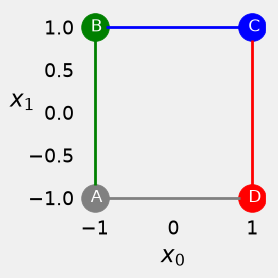

In [259]:
# 可视化: 数据形状
fig = counter_vs_clock(draw_arrows=False)

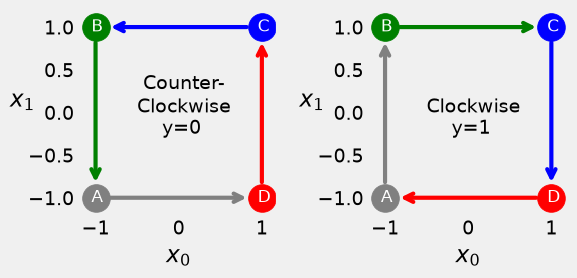

In [260]:
# 可视化: 形状与序列顺序
fig = counter_vs_clock()

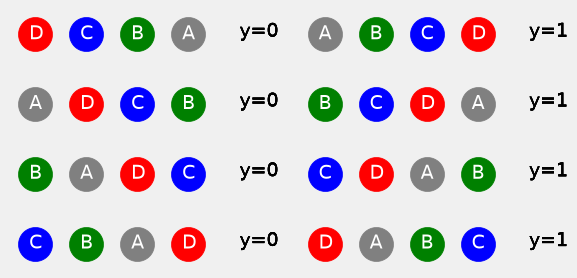

In [261]:
# 可视化: 所有可能的顺序
fig = plot_sequences()

(128, 4, 2) (128,)
[[ 1.03487506  0.96613817]
 [ 0.80546093 -0.91690943]
 [-0.82507582 -0.94988627]
 [-0.86696831  0.93424827]] 1


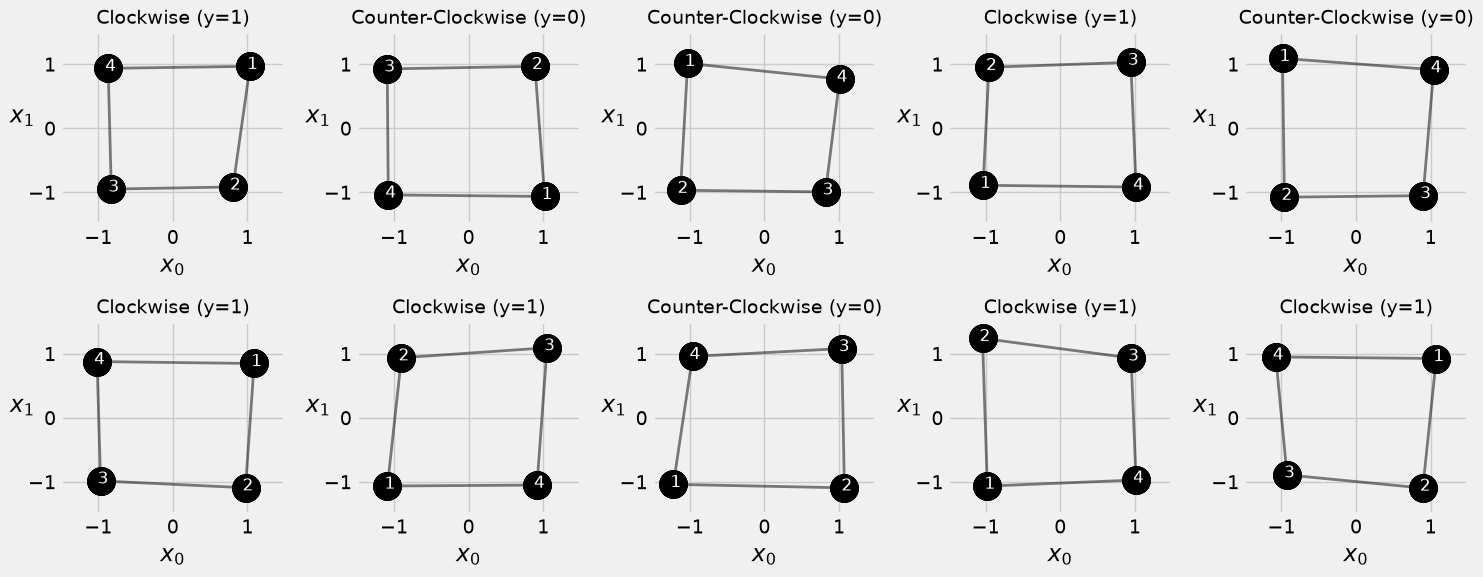

In [262]:
# 程序8-1: 生成数据
points, directions = generate_sequences(n=128, seed=13)

# 128组: 每组4点2维坐标
# 128组: 标签: 1顺时针 0 逆时针
# 1234为组内坐标顺序为绘制顺序
print(np.array(points).shape,np.array(directions).shape)

# 含有噪声的点,标签
print(points[0],directions[0]) 

# 可视化结果
fig = plot_data(points, directions)

> 目前引出了序列是有序的数据这一概念，并以二维图像数据（给两角预测剩余两角为问题）直观的作为问题

----

# 循环神经网络RNN

**Q**:解释术语:
- 隐藏状态

**Q**:回答问题:
- RNN解决的问题是什么？（从隐藏状态的角度出发）
- 作图:RNN的执行流程图是什么样的？
- 文字描述RNN的执行流程（5个步骤）
- 隐藏状态的初始状态代表了什么？
- 最终的隐藏状态代表了什么？


**Q**: 类比:
- 最终的隐藏状态和CNN的卷积块输出有什么异同？
- RNN的单元和CNN比有什么特点？

![](images/rnn2.png)

> RNN的循环意味着反复使用一个单元，上一步的输出状态加上新一步的外部数据就是下一步的输入数据

## RNN单元

**Q**: 回答问题:
- RNN单元的内部结构由什么构成？（数据操作,激活函数）
- RNN处理过程用表达式怎么表示？
- 作图: 神经元层面的RNN单元如何表示？
- 隐藏状态和输入数据在形状上有什么关系？

**Q**: 回答问题
- 为什么要使用特定的激活函数？有什么优势？

**Q**: 结合代码:
- 翻译代码步骤
- 使用`rnn_cell`要注意什么？


![](images/rnn1.png)


![](images/rnn_cell_diagram.png)




In [263]:
# 程序8-2 手动模拟RNN单元的一次计算

# 程序8-2-1: 初始化一个RNN单元(作为参数设置和对比工具)

# 程序8-2-2: 手动复现RNN单元内部的线性层

# 程序8-2-3: 初始化空序列的初始隐藏状态

# 程序8-2-4: 计算隐藏层

# 程序8-2-5: 选一个点计算输入层

# 程序8-2-6: 合并两层结果并使用激活函数

# 程序8-2-7: 测试对比结果（并可视化过程）

In [264]:
# 程序8-2-1: 如何初始化一个RNN单元

# 输入特征的维度（每个时间步的数据有2个特征，即2D坐标点）
n_features = 2
# 隐藏状态的维度（隐藏层神经元数量，设为2便于可视化）
hidden_dim = 2


torch.manual_seed(19)

# RNNCell处理单个时间步
rnn_cell = nn.RNNCell(input_size=n_features, hidden_size=hidden_dim)
rnn_state = rnn_cell.state_dict()
# 打印参数：
# weight_ih: 输入→隐藏层的权重矩阵, 形状(n_features, hidden_dim)的展平 → 实际为(hidden_dim, n_features)
# weight_hh: 隐藏层→隐藏层的权重矩阵, 形状(hidden_dim, hidden_dim)
# bias_ih: 输入→隐藏层的偏置, 形状(hidden_dim,)
# bias_hh: 隐藏层→隐藏层的偏置, 形状(hidden_dim,)
print(rnn_state)

OrderedDict([('weight_ih', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih', tensor([0.4954, 0.6533])), ('bias_hh', tensor([-0.3565, -0.2904]))])


In [265]:
# 程序8-2-2: 手动复现RNN单元内部的线性层

# RNNCell内部实际就是: tanh(Linear_input(x) + Linear_hidden(h))


# Linear层：对输入x做线性变换 W_ih @ x + b_ih
linear_input = nn.Linear(n_features, hidden_dim)
# Linear层：对上一时刻隐藏状态h做线性变换 W_hh @ h + b_hh
linear_hidden = nn.Linear(hidden_dim, hidden_dim)

# 在torch.no_grad()上下文中，将RNNCell的参数复制给两个Linear层
# 这样Linear层就和RNNCell具有完全相同的权重
with torch.no_grad():
    # 将RNNCell的输入权重和偏置复制给linear_input
    linear_input.weight = nn.Parameter(rnn_state['weight_ih'])
    linear_input.bias = nn.Parameter(rnn_state['bias_ih'])
    # 将RNNCell的隐藏层权重和偏置复制给linear_hidden
    linear_hidden.weight = nn.Parameter(rnn_state['weight_hh'])
    linear_hidden.bias = nn.Parameter(rnn_state['bias_hh'])

print(linear_input.state_dict())
print(linear_hidden.state_dict())

OrderedDict([('weight', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('bias', tensor([0.4954, 0.6533]))])
OrderedDict([('weight', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias', tensor([-0.3565, -0.2904]))])


In [266]:
# 程序8-2-3: 初始化空序列的初始隐藏状态

initial_hidden = torch.zeros(1, hidden_dim)
print(initial_hidden)

tensor([[0., 0.]])


In [267]:
# 程序8-2-4: 计算隐藏层

th = linear_hidden(initial_hidden)
print(th)

tensor([[-0.3565, -0.2904]], grad_fn=<AddmmBackward0>)


In [268]:
# 程序8-2-5: 选一个点计算输入层
X = torch.as_tensor(points[0]).float()
print(X)

tx = linear_input(X[0:1])
print(tx)

tensor([[ 1.0349,  0.9661],
        [ 0.8055, -0.9169],
        [-0.8251, -0.9499],
        [-0.8670,  0.9342]])
tensor([[0.7712, 1.4310]], grad_fn=<AddmmBackward0>)


In [269]:
# 程序8-2-6: 合并两层结果并使用激活函数

adding = th + tx
print(adding)

# 激活函数: 压缩范围
print(torch.tanh(adding))

tensor([[0.4146, 1.1405]], grad_fn=<AddBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


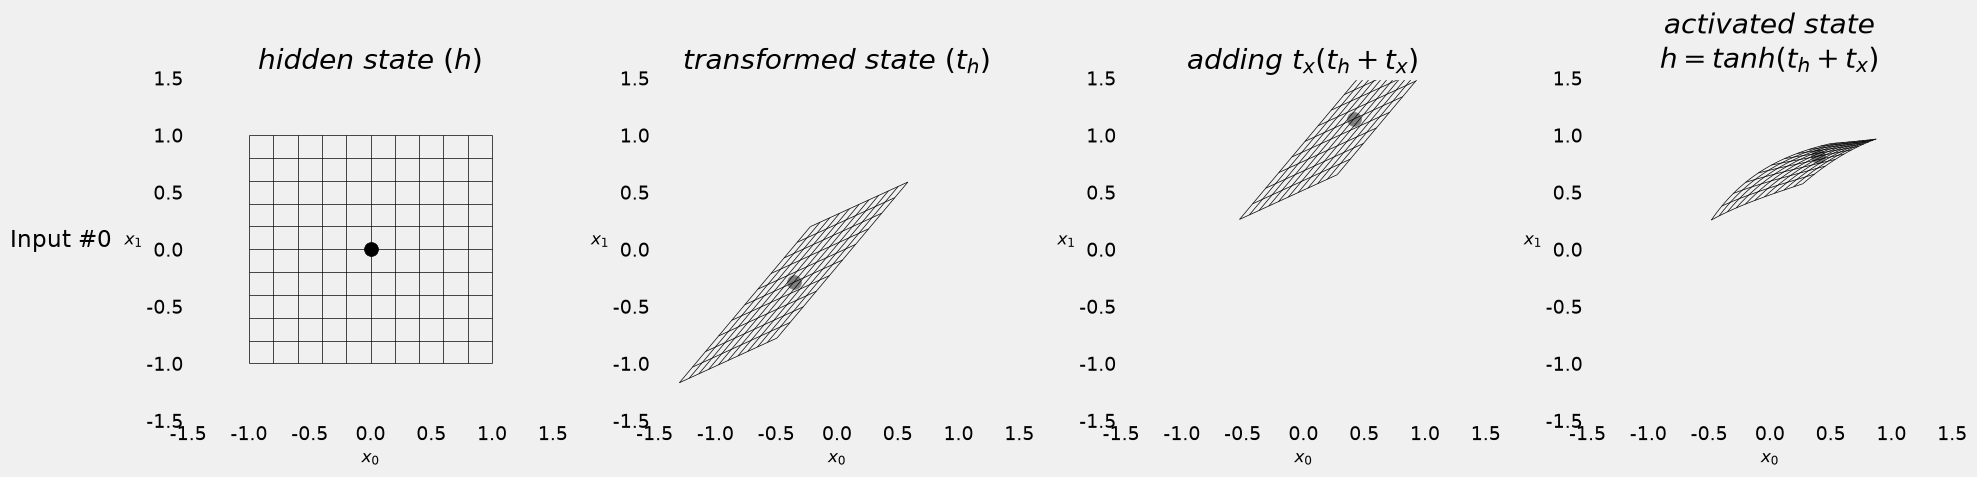

In [270]:
# 程序8-2-7: 测试对比结果并可视化过程

# 直接用RNNCell处理X[0:1]（第1个时间步的坐标点），与前面分步计算的结果对比
print(rnn_cell(X[0:1]))

# figure8函数将RNN单元内部处理过程分解为4个子图进行可视化：
# 子图1: hidden state (h)     — 当前隐藏状态在特征空间中的位置
# 子图2: transformed state    — 隐藏层线性变换结果 W_hh@h + b_hh
# 子图3: adding t_h+t_x       — 隐藏变换与输入变换相加，信息融合
# 子图4: activated state      — tanh激活后的新隐藏状态 h' = tanh(t_h+t_x)
# 注意: 子图1→子图4的变化即RNN对单个时间步的处理过程
fig = figure8(linear_hidden, linear_input, X)

In [271]:
# 程序8-3: rnn_cell的使用注意事项(实现一个序列的RNN)

print(hidden_dim)
print(X.shape[0])

# 这样做只代表4个点的第一步
# ps：不提供状态则默认初始状态
print(rnn_cell(X))

# 这才是从1-4的4步RNN
hidden = torch.zeros(1, hidden_dim)
for i in range(X.shape[0]):
    out = rnn_cell(X[i:i+1], hidden)
    print(out)
    hidden = out

2
4
tensor([[ 0.3924,  0.8146],
        [ 0.7864,  0.5266],
        [-0.0047, -0.2897],
        [-0.6817,  0.1109]], grad_fn=<TanhBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)
tensor([[ 0.4347, -0.0481]], grad_fn=<TanhBackward0>)
tensor([[-0.1521, -0.3367]], grad_fn=<TanhBackward0>)
tensor([[-0.5297,  0.3551]], grad_fn=<TanhBackward0>)


> 上述循环可用下图表示

![](images/rnn_cell_diagram_seq.png)

> RNN单元的内部是由两个线性层求和+一个Tanh激活函数组成，线性层计算的分别是本次的输入数据和隐藏状态

>`RNNCell`是RNN单元的抽象类，需要两个输入，即数据和隐藏状态

---

## RNN层

**Q**: 解释RNN的参数意义
- input_size
- hidden_size
- bias
- nolinearity

**Q**: 解释RNN的参数意义2
- num_layers
- bidirectional
- dropout
- batch_first

**Q**:一句话回答问题
- 堆叠RNN是什么？
- 双向RNN是什么

**Q**:结合代码结果
- `state_dict`返回的参数名称的后缀代表什么？

In [272]:
# 程序8-4: RNN层的使用

n_features = 2
hidden_dim = 2

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)

# 注意和自定义的RNNCell初始化的结果是一样的
print(rnn.state_dict())

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904]))])


> RNN层封装了RNNCell的计算循环，除了提供基本的输入size和隐藏层size还可指定激活函数和RNN的内部层(堆叠和双向),另外还可在堆叠中加dropout和规定序列的形状
---

## 形状

暂未明确解释的术语:
- 打包序列

**Q**: 回答问题
- RNN需要的输入输出张量形状是什么?(非batch_first下)
- RNN需要的输入输出张量形状是什么?(batch_first下)
- 初始隐藏状态默认是什么?
- 隐藏状态的形状是什么？进一步堆叠和双向形状分别是什么？
- 输出张量形状是什么?(batch_first下和非batch_first下)(堆叠和双向下)？

**Q**: 结合代码
- `permute`的作用？

In [273]:
# 程序8-5 研究RNN层输入和输出的形状

# 程序8-5-1: 生成数据的形状

# 程序8-5-2: permute的使用: 交换分量

# 程序8-5-3: RNN层计算和其特点

# 程序8-5-4: 手动隐藏层转为batch_first

# 程序8-5-5: 注意batch_first影响的对象

In [274]:
# 程序8-5-1: 生成数据的结构

# points(128, 4, 2) direction(128,)
batch = torch.as_tensor(points[:3]).float()

# (N L F)batch_first格式: 批量大小 序列长度 特征数量
print(batch.shape)

torch.Size([3, 4, 2])


In [275]:
# 程序8-5-2: permute的使用: 交换分量
permuted_batch = batch.permute(1, 0, 2)

# RNN友好格式(序列优先): L N F
print(permuted_batch.shape)

torch.Size([4, 3, 2])


In [276]:
# 程序8-5-3: RNN层计算和其特点

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)
out, final_hidden = rnn(permuted_batch)

# 结果也是序列优先
print(out.shape, final_hidden.shape)

# 最后输出即是最终隐藏层
print((out[-1] == final_hidden).all())

torch.Size([4, 3, 2]) torch.Size([1, 3, 2])
tensor(True)


In [277]:
# 程序8-5-4: 手动隐藏层转为batch_first

batch_hidden = final_hidden.permute(1, 0, 2)
print(batch_hidden.shape)

torch.Size([3, 1, 2])


In [278]:
# 程序8-5-5: 注意batch_first影响的对象

torch.manual_seed(19)
rnn_batch_first = nn.RNN(input_size=n_features, hidden_size=hidden_dim, batch_first=True)
out, final_hidden = rnn_batch_first(batch)
print(out.shape, final_hidden.shape)

torch.Size([3, 4, 2]) torch.Size([1, 3, 2])


> RNN友好格式LNF,隐藏格式1NH,1受双向和堆叠影响2*堆叠层或对叠层数，输出LNH,H受受双向和堆叠影响2H和H,batch_first不影响最终隐藏层状态shape

> RNN最终状态应该和最后输出的最后一个元素相同
---

## 堆叠RNN

**Q**: 回答问题
- 堆叠RNN的结构是什么样的?(输入，层，输出)
- 序列每一步的隐藏状态位于哪一层？
- 堆叠RNN的整体输出结构包含哪两种元素？
- 输出的最后一个元素是什么？

**Q**: 结合代码
- `torch.cat`的作用

![](images/stacked_rnn.png)

In [279]:
# 程序8-6 对比手动和封装RNN层的行为

# 程序8-6-1: 运行堆叠RNN获得参数

# 程序8-6-2: 手动模拟初始化堆叠RNN两层

# 程序8-6-3: 手动模拟堆叠RNN的两层计算

# 程序8-6-4: 生成对比结果

In [280]:
# 程序8-6-1: 运行堆叠RNN获得参数
torch.manual_seed(19)
rnn_stacked = nn.RNN(input_size=2, hidden_size=2, num_layers=2, batch_first=True)
state = rnn_stacked.state_dict()
print(state)

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904])), ('weight_ih_l1', tensor([[-0.6701, -0.5811],
        [-0.0170, -0.5856]])), ('weight_hh_l1', tensor([[ 0.1159, -0.6978],
        [ 0.3241, -0.0983]])), ('bias_ih_l1', tensor([-0.3163, -0.2153])), ('bias_hh_l1', tensor([ 0.0722, -0.3242]))])


In [281]:
# 程序8-6-2: 手动模拟初始化堆叠RNN两层
rnn_layer0 = nn.RNN(input_size=2, hidden_size=2, batch_first=True)
rnn_layer1 = nn.RNN(input_size=2, hidden_size=2, batch_first=True)

# 取第0层的所有参数
rnn_layer0.load_state_dict(dict(list(state.items())[:4]))
# 取高一层的所有参数,并手动修改key的名称为第0层
rnn_layer1.load_state_dict(dict([(k[:-1]+'0', v) for k, v in list(state.items())[4:]]))

<All keys matched successfully>

In [282]:
# 程序8-6-3: 手动模拟堆叠RNN的两层计算

# points(128, 4, 2)
# 抽一个序列来进行计算
x = torch.as_tensor(points[0:1]).float()
print(x.shape)

# 计算第一层
out0, h0 = rnn_layer0(x)
print(out0.shape,h0.shape)

# 计算第二层
out1, h1 = rnn_layer1(out0)
print(out1.shape,h1.shape)

# 输出结果
# torch.cat在dim=0上拼接两层的隐藏状态: h0(1,1,2) + h1(1,1,2) → (2,1,2)
# 其中dim=0的2代表堆叠层数, 与堆叠RNN的final_hidden形状一致
print(out1.shape, torch.cat([h0, h1]).shape)

torch.Size([1, 4, 2])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
torch.Size([1, 4, 2]) torch.Size([2, 1, 2])


In [283]:
# 程序8-6-4: 生成对比结果
out, hidden = rnn_stacked(x)
print(out.shape, hidden.shape)

# 对比结果
## [:, -1] 做了两件事：
## : — 第一个维度（batch）全取
## -1 — 第二个维度取最后一个
### 注意permute转换形状
(out[:, -1] == hidden.permute(1, 0, 2)[:, -1]).all()

torch.Size([1, 4, 2]) torch.Size([2, 1, 2])


tensor(True)

> 堆叠RNN将RNN层垒起来,底层的输入是x，往上每层的输入都是下一层的隐藏状态，最终隐藏状态就是输出结果的最后一个元素

## 双向RNN


**Q**: 回答问题
- 双向RNN的结构是什么样的?(输入，层，输出)
- 堆叠RNN的整体输出结构包含哪些元素？（注意形状）

**Q**: 结合代码
- `torch.flip` + `dim`的作用
- `torch.cat`+ `dim`的作用
- 为什么最后对比只有一半对上？

![](images/bidirect_rnn.png)

In [284]:
# 程序8-6-1: 运行双向RNN获得参数

torch.manual_seed(19)
rnn_bidirect = nn.RNN(input_size=2, hidden_size=2, bidirectional=True, batch_first=True)
state = rnn_bidirect.state_dict()
print(state)

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904])), ('weight_ih_l0_reverse', tensor([[-0.6701, -0.5811],
        [-0.0170, -0.5856]])), ('weight_hh_l0_reverse', tensor([[ 0.1159, -0.6978],
        [ 0.3241, -0.0983]])), ('bias_ih_l0_reverse', tensor([-0.3163, -0.2153])), ('bias_hh_l0_reverse', tensor([ 0.0722, -0.3242]))])


In [285]:
# 程序8-6-2: 手动模拟初始化双向RNN两层

rnn_forward = nn.RNN(input_size=2, hidden_size=2, batch_first=True)
rnn_reverse = nn.RNN(input_size=2, hidden_size=2, batch_first=True)

rnn_forward.load_state_dict(dict(list(state.items())[:4]))
rnn_reverse.load_state_dict(dict([(k[:-8], v) for k, v in list(state.items())[4:]]))

<All keys matched successfully>

In [286]:
# 程序8-6-3: 手动模拟双向RNN的两层计算

# torch.flip沿dim=1(序列长度L)将序列前后翻转: [t1,t2,t3,t4] → [t4,t3,t2,t1]
# 翻转后的序列喂给反向RNN，实现从后往前处理序列
x_rev = torch.flip(x, dims=[1]) # N, L, F
print(x_rev)

# 正向RNN处理原始序列
out, h = rnn_forward(x)
print(out.shape, h.shape)
# 反向RNN处理翻转后的序列
out_rev, h_rev = rnn_reverse(x_rev)
print(out_rev, h_rev)
# 再次flip将反向输出翻回正向时序，使其与out对齐以便拼接
out_rev_back = torch.flip(out_rev, dims=[1])
print(out_rev_back)


tensor([[[-0.8670,  0.9342],
         [-0.8251, -0.9499],
         [ 0.8055, -0.9169],
         [ 1.0349,  0.9661]]])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
tensor([[[-0.2032, -0.7901],
         [ 0.8829,  0.0425],
         [-0.1766,  0.2596],
         [-0.9355, -0.8353]]], grad_fn=<TransposeBackward1>) tensor([[[-0.9355, -0.8353]]], grad_fn=<StackBackward0>)
tensor([[[-0.9355, -0.8353],
         [-0.1766,  0.2596],
         [ 0.8829,  0.0425],
         [-0.2032, -0.7901]]], grad_fn=<FlipBackward0>)


In [287]:
# 程序8-6-3-1: 拼接正反向输出，与双向RNN对比

# dim=2: 在特征维拼接正反向输出, out(1,4,2)+out_rev_back(1,4,2)→(1,4,4)
# 双向RNN在特征维拼接前后向信息, 使每个时间步都能看到上下文
# dim=0: cat([h, h_rev])在层数维拼接, h(1,1,2)+h_rev(1,1,2)→(2,1,2)
print(torch.cat([out, out_rev_back], dim=2).shape, torch.cat([h, h_rev]).shape)

torch.Size([1, 4, 4]) torch.Size([2, 1, 2])


In [288]:
# 程序8-6-4: 生成对比结果

out, hidden = rnn_bidirect(x)
print(out.shape, hidden.shape)

# 验证输出最后一个时间步与最终隐藏状态的关系
# out[:, -1]形状(1,4): 取最后一个时间步t4的输出 [forward_t4(2) + backward_t4(2)]
# hidden形状(2,1,2): dim=0=[forward最终隐藏, backward最终隐藏]
# hidden.permute(1,0,2) → (1,2,2) 再 .view(1,-1) → (1,4) 展平对齐
# 结果[True,True,False,False]:
#   前两个True: out[:,-1,:2] == hidden[0], forward最终隐藏=处理完t4的状态 ✓
#   后两个False: out[:,-1,2:] != hidden[1], backward最终隐藏对应原始序列t1时刻,
#               但out[:,-1]取的是t4时刻的backward输出, 所以不匹配 ✗
# 对比堆叠RNN: 堆叠RNN中out[:,-1]==顶层隐藏; 双向RNN中只有forward一半匹配
print(out[:, -1] == hidden.permute(1, 0, 2).view(1, -1))

torch.Size([1, 4, 4]) torch.Size([2, 1, 2])
tensor([[ True,  True, False, False]])


> 双向RNN分别计算了相反方向的RNN并产生两组不同的隐藏状态，输入都是x，输出时out会反转为正向，但隐藏层并不会反转；在拼接结果时out会拼接序列维度

# 正方形模型

In [289]:
# 程序8-7 封装整个RNN过程

# 程序8-7-1: 生成测试数据

# 程序8-7-2: 构建DataSet和Loader

# 程序8-7-3: 构建RNN分类模型

# 程序8-7-4: 配置模型，损失函数，优化器

# 程序8-7-5: 训练循环

# 程序8-7-6: 可视化

# 程序8-7-7: 评价结果

## 数据生成

In [290]:
# 程序8-7-1: 生成测试数据

# 在程序8-1中已生成训练数据
# points, directions = generate_sequences(n=128, seed=13)
test_points, test_directions = generate_sequences(n=128,seed=19)

## 数据准备

In [291]:
# 引入

## 数据加载和数据集
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset

# 优化器
import torch.optim as optim

# 处理类
from stepbystep.v4 import StepByStep

In [292]:
# 程序8-7-2: 构建DataSet和Loader

# TensorDataset: (特征,标签)
train_data = TensorDataset(torch.as_tensor(points).float(), 
                torch.as_tensor(directions).view(-1, 1).float())
test_data = TensorDataset(torch.as_tensor(test_points).float(),
                torch.as_tensor(test_directions).view(-1, 1).float())

# 注意训练数据需要打乱
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

In [293]:
# 程序8-7-3: 构建RNN分类模型

# 设计意图: 用RNN编码4个点的序列信息，取最后一步隐藏状态作为序列的"特征摘要"，
#          再通过线性层将该摘要映射为二分类logits（顺时针=1 / 逆时针=0）

class SquareModel(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs):
        super(SquareModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        # 保存最后一层的隐藏状态，供外部检查
        self.hidden = None
        # 基础RNN层: 将整个序列(N,L,F)编码为每个时间步的隐藏表示(N,L,H)
        self.basic_rnn = nn.RNN(self.n_features, self.hidden_dim, batch_first=True)
        # 分类器: 将RNN最后一个时间步的隐藏状态(H)映射为预测logits
        # 意图: RNN隐藏状态已"记忆"了整个序列的时序信息，线性层只需将其映射到分类空间
        # 输出1个logit用于二分类(顺时针/逆时针)，配合BCEWithLogitsLoss不需要显式sigmoid
        self.classifier = nn.Linear(self.hidden_dim, self.n_outputs)
                
    def forward(self, X):
        # X形状: batch_first (N, L, F) — 批量大小, 序列长度, 特征数
        # batch_first_output: (N, L, H) — 每个时间步的隐藏状态
        # self.hidden: (1, N, H) — 最终隐藏状态(层数=1)
        batch_first_output, self.hidden = self.basic_rnn(X)
        
        # 意图: 只取最后一个时间步的输出(N,H)，而非所有时间步(N,L,H)
        # 原因: RNN的最后一步隐藏状态已经累积了整个序列的信息，可代表整个序列
        # 对比: 如果用所有时间步做平均池化也能保留全局信息，但最后一步更简单直接
        last_output = batch_first_output[:, -1]
        # 分类器输出: (N, n_outputs), 将隐藏状态映射为分类logits
        out = self.classifier(last_output)
        
        # 展平为(N, n_outputs), 与标签形状对齐用于BCEWithLogitsLoss
        return out.view(-1, self.n_outputs)

In [294]:
# 程序8-7-4: 配置模型，损失函数，优化器
torch.manual_seed(21)
model = SquareModel(n_features=2, hidden_dim=2, n_outputs=1)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [295]:
# 程序8-7-5: 训练循环
sbs_rnn = StepByStep(model, loss, optimizer)
sbs_rnn.set_loaders(train_loader, test_loader)
sbs_rnn.train(100)

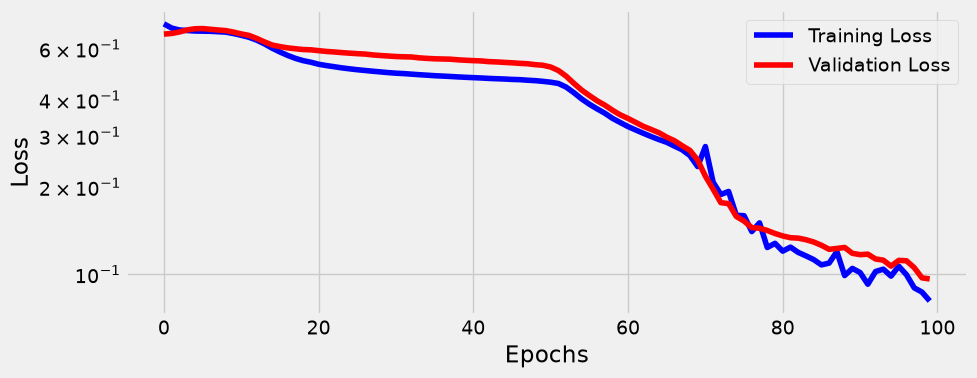

In [296]:
# 程序8-7-6: 可视化
fig = sbs_rnn.plot_losses()

In [297]:
# 程序8-7-7: 评价结果

# correct()返回的是每类的[正确数, 总数]，不是混淆矩阵
# 第0行: 类别0(逆时针↺) — 53个样本中50个预测正确, 准确率94.3%
# 第1行: 类别1(顺时针↻) — 75个样本中75个预测正确, 准确率100%
# 整体: 128个测试样本中125个正确, 准确率97.7%
StepByStep.loader_apply(test_loader, sbs_rnn.correct)

tensor([[50, 53],
        [75, 75]])

> 整个训练过程应包括: 数据生成(训练,测试),数据准备(数据集和Loader,训练数据要打乱),建立模型类(继承`nn.Module`,主要功能是`forward`前向传播)(RNN提取特征+Linear分类器),配置(模型,损失函数,优化器)(二分BCE)，训练，可视化损失，评价结果

## 可视化模型

In [ ]:
# 程序8-8

# 程序8-8-1 : 查看训练后模型的RNN层参数

# 程序8-8-2: 模型对输入做相同的仿射变换，数据点独立转换

# 程序8-8-3: 可视化隐藏状态空间的决策边界：代表最终隐藏状态的样子

# 程序8-8-4: 可视化隐藏状态随时间的演化

# 程序8-8-5: 可视化训练后RNN逐时间步的特征空间变换过程（每一行初始隐藏状态都是上一行的激活状态）

# 程序8-8-6: 用完美正方形测试训练后模型, 观察最终隐藏状态

# 程序8-8-7: 可视化隐藏状态在特征空间中的路径轨迹（记录8-8-5的运行轨迹）

In [298]:
# 程序8-8-1: 查看训练后模型的RNN层参数

# 提取训练100轮后 basic_rnn 的权重和偏置
# 对比 程序8-2-1 的初始随机参数(weight_ih ≈ [[0.66,-0.42],[0.54,0.23]]),
# 这里 weight_ih_l0 = [[-0.52,-2.66],[-1.70,-0.50]] 已经完全不同,
# 说明RNN通过梯度下降学会了从2D坐标点中提取方向特征

# weight_ih_l0 形状 (hidden_dim=2, n_features=2):
#   第0行 [-0.5201, -2.6582] — 神经元0对两个输入特征的权重
#   第1行 [-1.7018, -0.4989] — 神经元1对两个输入特征的权重
# bias_ih_l0 形状 (hidden_dim=2,):
#   [0.8096, 0.8822] — 两个神经元的输入偏置

state = model.basic_rnn.state_dict()
state['weight_ih_l0'], state['bias_ih_l0']

(tensor([[-0.5201, -2.6582],
         [-1.7018, -0.4989]]),
 tensor([0.8096, 0.8822]))

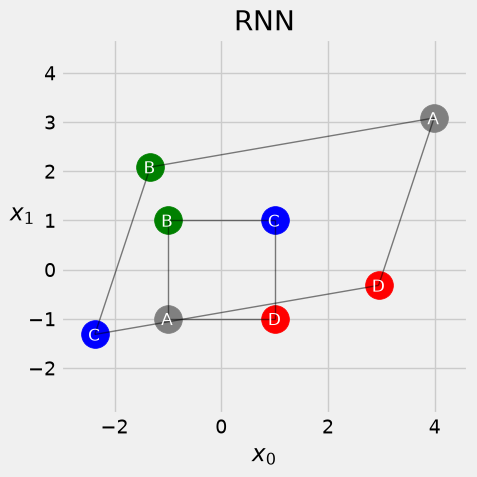

In [299]:
# 程序8-8-2: 可视化训练后RNN的输入变换

# figure13 内部流程:
#   1. 构造一个无噪声的完美正方形(顺时针A→B→C→D), 形状(1,4,2)
#   2. 拆解RNN取出 linear_input 层 (W_ih @ x + b_ih)
#   3. 调用 transformed_inputs 将4个角点分别通过 linear_input 做线性变换
#
# 图中显示两组4个点:
#   灰色/绿/蓝/红色点(右侧): 原始4个角点在2D坐标空间的位置 A(-1,-1) B(-1,1) C(1,1) D(1,-1)
#   灰色/绿/蓝/红色点(左侧): 经训练后线性层投影到隐藏空间的位置 W_ih@A+b_ih 等
#
# 设计意图: 直观展示RNN的第一步——原始几何坐标如何被线性映射到隐藏特征空间,
#         训练后的权重使得这个映射对分类任务有意义(顺时针vs逆时针)

fig = figure13(model.basic_rnn)

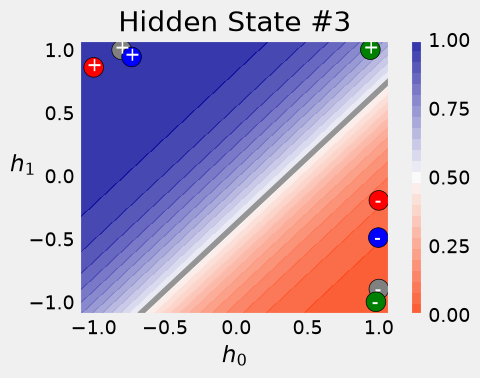

In [300]:
# 程序8-8-3: 可视化隐藏状态空间的决策边界

# canonical_contour 内部流程:
#   1. 生成8条"规范路径"(canonical sequences):
#      4条顺时针: 分别从A/B/C/D四个角出发, 沿正方形顺时针走一圈
#      4条逆时针: 分别从A/B/C/D四个角出发, 沿正方形逆时针走一圈
#      (无噪声, 每个角都是精确的[-1,-1][-1,1][1,1][1,-1])
#   2. 8条序列通过 model → 得到8个最终隐藏状态 h₃ (形状 8×2)
#   3. 在隐藏状态空间 (h₀, h₁) 上绘制 model.classifier 的概率等高线
#      并将8个隐藏状态点叠加在等高线上
#
# 图中解读:
#   背景色: 分类器在隐藏空间的决策区域
#     红色区域 → 预测为顺时针(1), 蓝色区域 → 预测为逆时针(0)
#   白色分割带: 概率≈0.5的分界区域(分类器不确定)
#   '+' 标记: 4条顺时针路径的最终隐藏状态(应落入红色区域)
#   '-' 标记: 4条逆时针路径的最终隐藏状态(应落入蓝色区域)
#
# 设计意图: 验证RNN是否学会了将不同方向的序列映射到隐藏空间中可线性分离的位置,
#          '+'和'-'泾渭分明则说明RNN成功提取了方向特征

fig = canonical_contour(model)

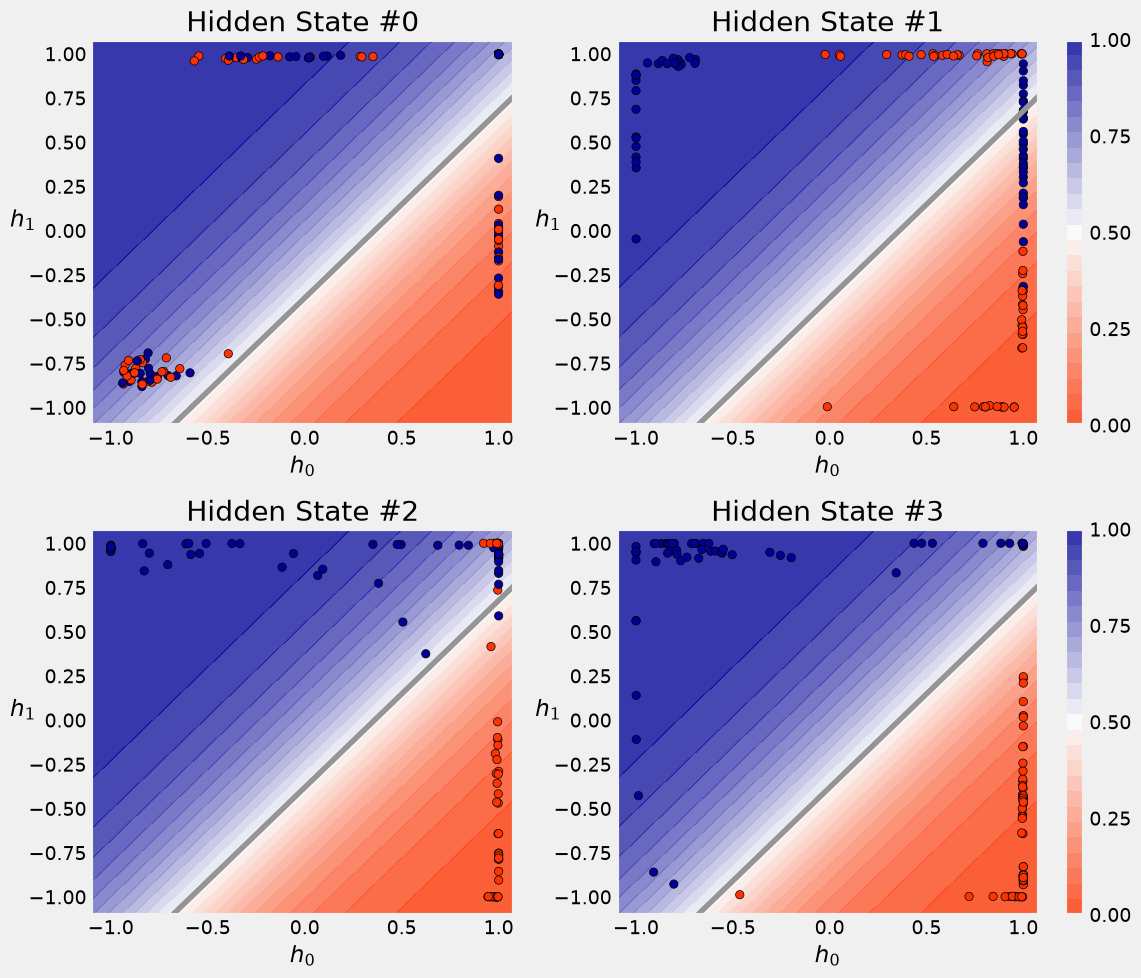

In [301]:
# 程序8-8-4: 可视化隐藏状态随时间的演化

# hidden_states_contour 内部流程:
#   2×2 子图布局, 分别对应4个时间步 (Hidden State #0 ~ #3)
#   每个子图i中:
#     - 将全部128个训练样本的前i+1个点(部分序列)送入model
#     - 取 model.hidden 在当前时间步的值作为散点坐标
#     - 背景等高线: classifier对隐藏空间中各点的概率预测
#       红色区域→预测顺时针, 蓝色区域→预测逆时针
#     - 散点颜色: 该样本的真实方向(红色=顺时针, 蓝色=逆时针)
#
# 图中解读(从左到右, 从上到下):
#   Hidden State #0: 只看了第1个点, 信息最少, 两类样本混杂在一起
#   Hidden State #1: 看了2个点, 开始出现一定的分离趋势
#   Hidden State #2: 看了3个点, 两类样本逐渐分离
#   Hidden State #3: 看完4个点的完整序列, 两类样本基本分开
#
# 设计意图: 展示信息在RNN隐藏状态中逐步累积的过程,
#         越往后两类样本在隐藏空间中分离得越清晰,
#         说明RNN确实在逐步"理解"序列的方向

fig = hidden_states_contour(model, points, directions)

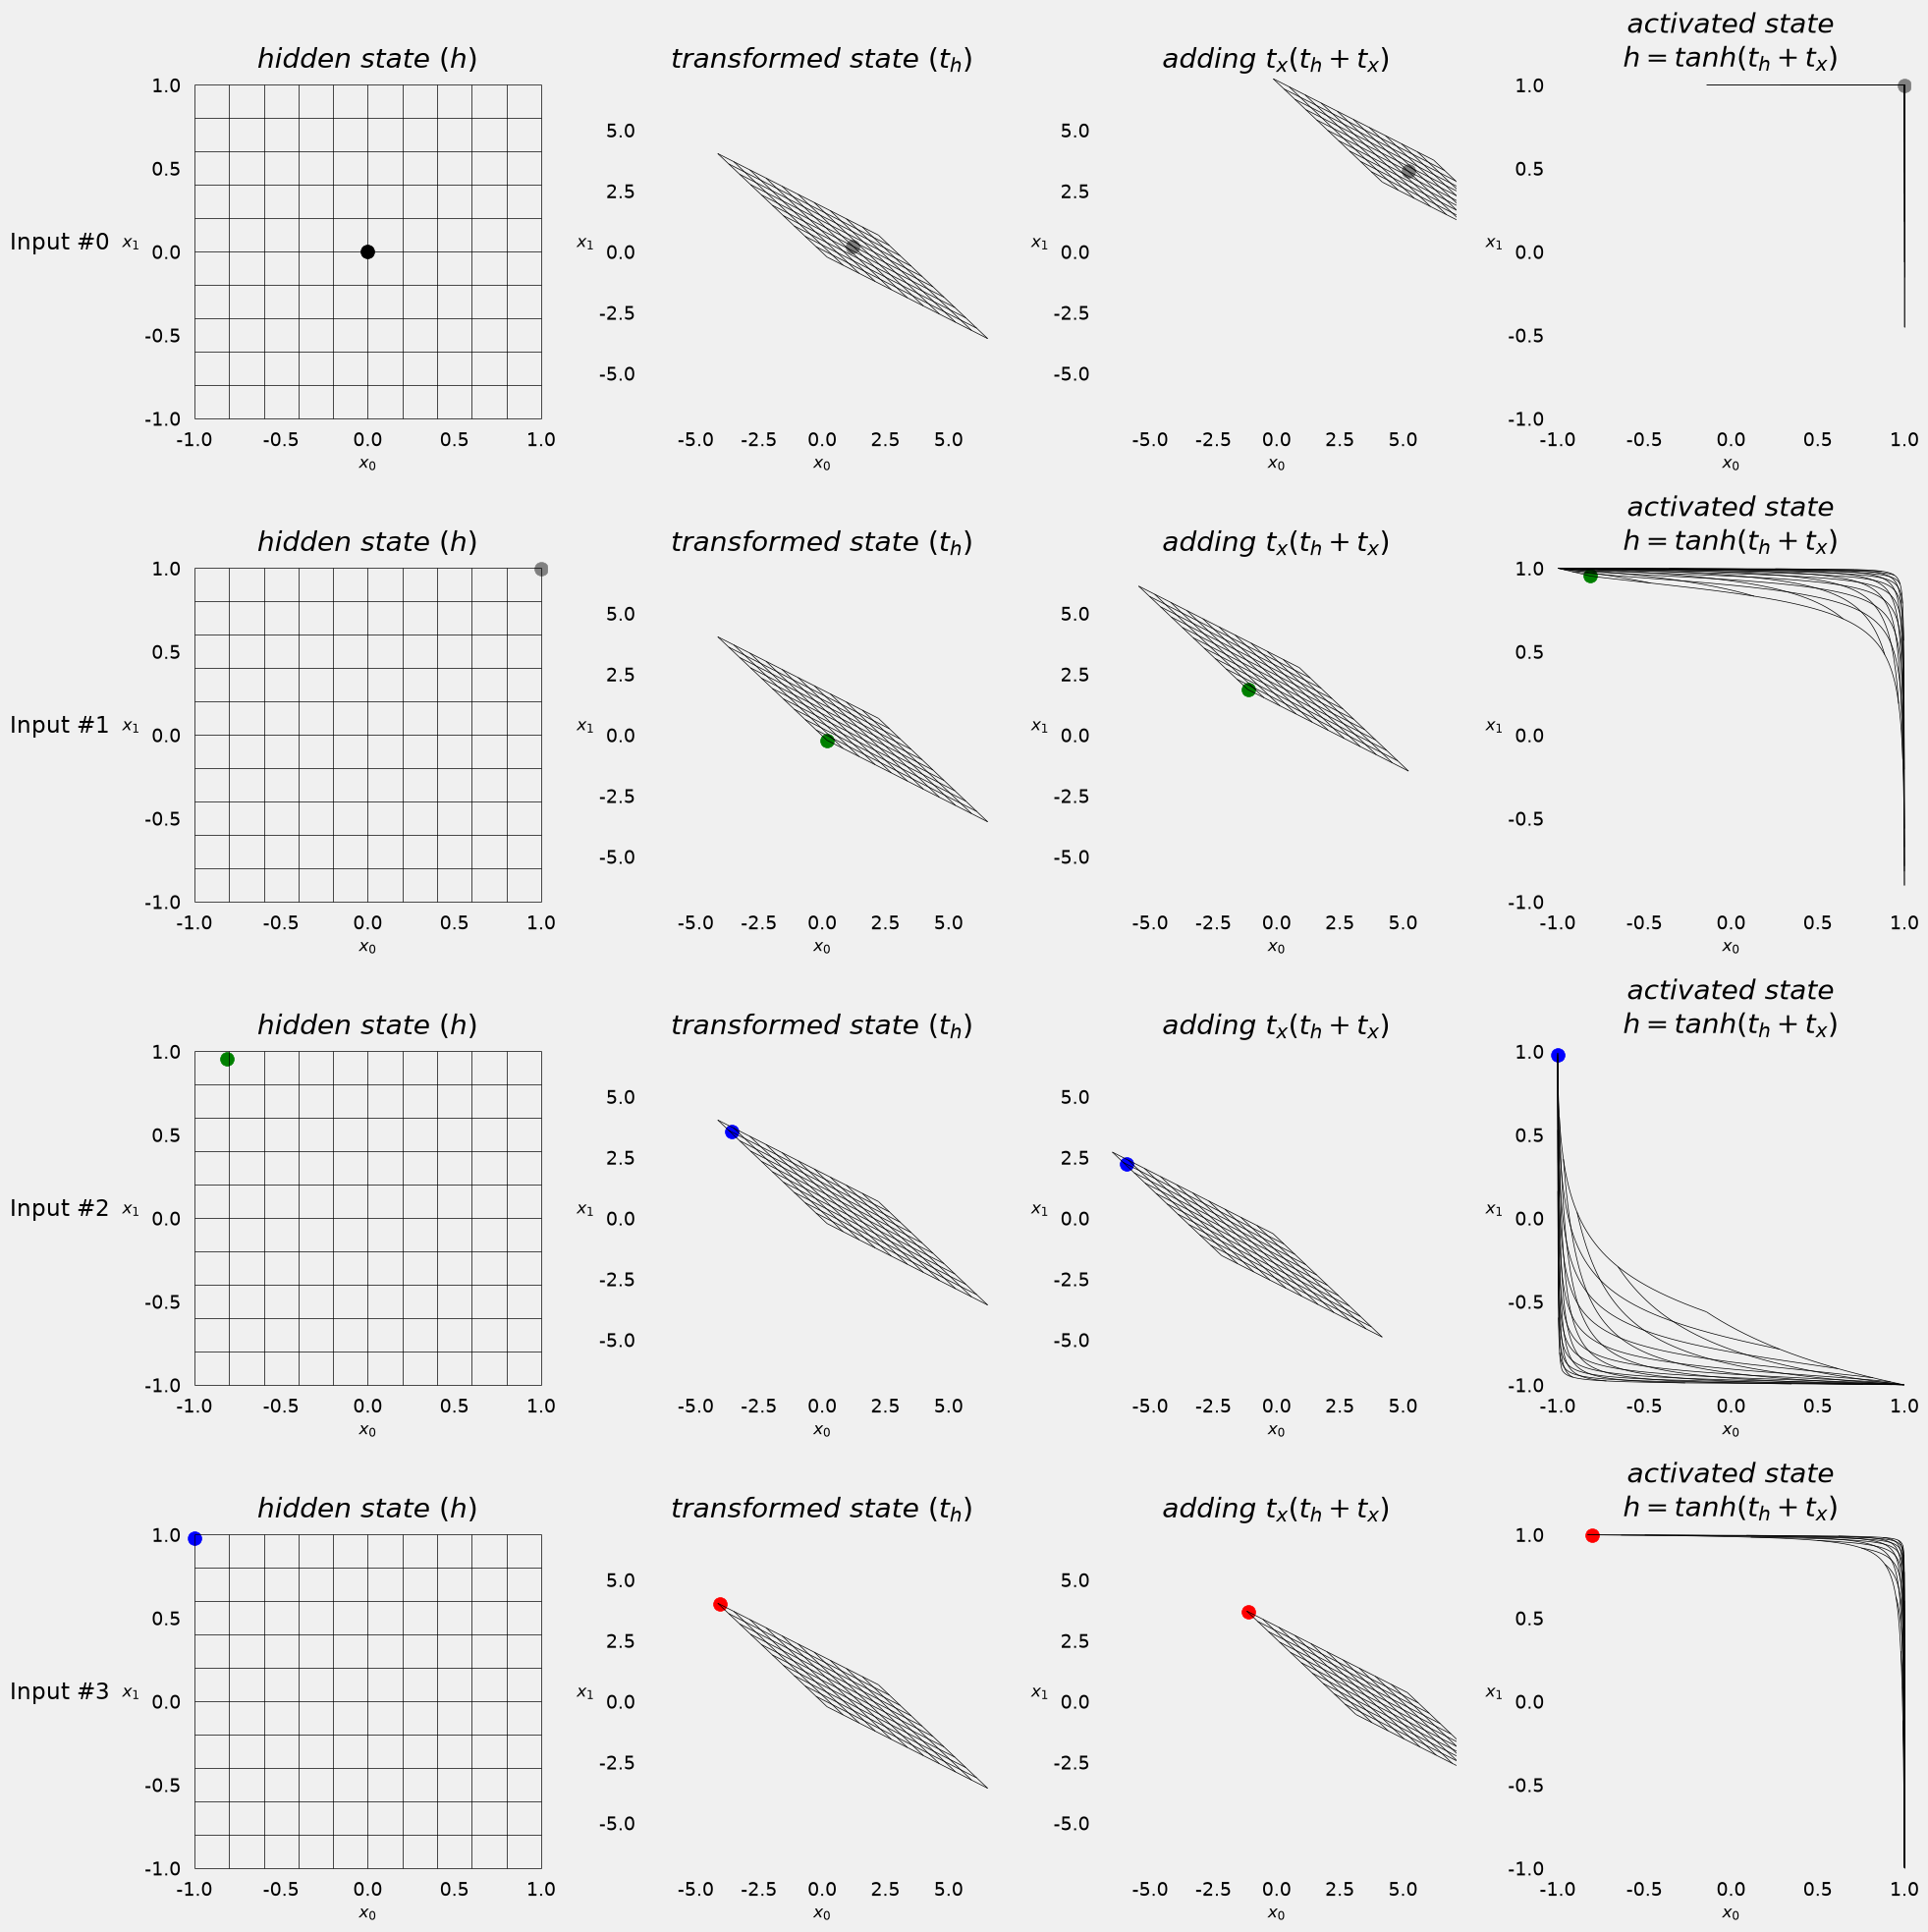

In [ ]:
# 程序8-8-5: 可视化训练后RNN逐时间步的特征空间变换过程

# figure16 内部流程:
#   1. 构造完美正方形(顺时针A→B→C→D), 形状(1,4,2)
#   2. 拆解RNN取出 linear_hidden 和 linear_input 两个线性层
#   3. 调用 generate_rnn_states 手动模拟4个时间步的RNN计算,
#      记录每一步的中间状态 th, tx, th+tx, tanh(th+tx)
#   4. 调用 feature_spaces 绘制子图矩阵:
#      4行 = 4个时间步(Input #0/#1/#2/#3, 对应正方形的4个角点)
#      多列 = RNN单元内部的变换阶段
#        hidden state(h) → transformed state(t_h) → adding t_x(t_h+t_x) → activated state(h'=tanh)
#
# 图中解读:
#   每个子图中彩色点(灰/绿/蓝/红) = 正方形4个角点在该变换阶段的位置
#   横向观察: 每个角点如何经过线性变换→相加→tanh激活逐步演化
#   纵向观察: 同一变换阶段, 不同时间步的隐藏状态如何随序列推进而变化
#
# 对比 程序8-2-7 的 figure8:
#   figure8 用初始随机权重, 变换看起来杂乱无章
#   figure16 用训练100轮后的权重, 变换有明确规律,
#   各角点在隐藏空间中的位置和轨迹服务于"顺时针/逆时针"分类目标


fig = figure16(model.basic_rnn)

In [303]:
# 程序8-8-6: 用完美正方形测试训练后模型, 观察最终隐藏状态

# 构造一个无噪声的完美正方形(顺时针A→B→C→D):
#   A(-1,-1) → B(-1,1) → C(1,1) → D(1,-1)
#   形状(1,4,2): 1个样本, 4个时间步, 2个特征
#   这是顺时针方向, 标签应为1

square = torch.tensor([[-1, -1], [-1, 1], [1, 1], [1, -1]]).float().view(1, 4, 2)

# 将正方形送入训练好的模型, 触发forward计算
# forward中会将 self.hidden 更新为最终隐藏状态
model(square.to(sbs_rnn.device))

# 查看最终隐藏状态, 形状(1,1,2):
#   dim=0为层数(1层), dim=1为batch(1个样本), dim=2为隐藏特征(2维)
# 这个2维向量就是RNN对"完美顺时针正方形"的编码摘要,
# classifier将基于它预测方向
#
# 对比训练数据(含噪声σ=0.1): 无噪声正方形是"理想情况",
# 如果模型训练得当, 该隐藏状态应落入 classifier 的顺时针高概率区域

model.hidden

tensor([[[-0.8040,  0.9987]]], grad_fn=<StackBackward0>)

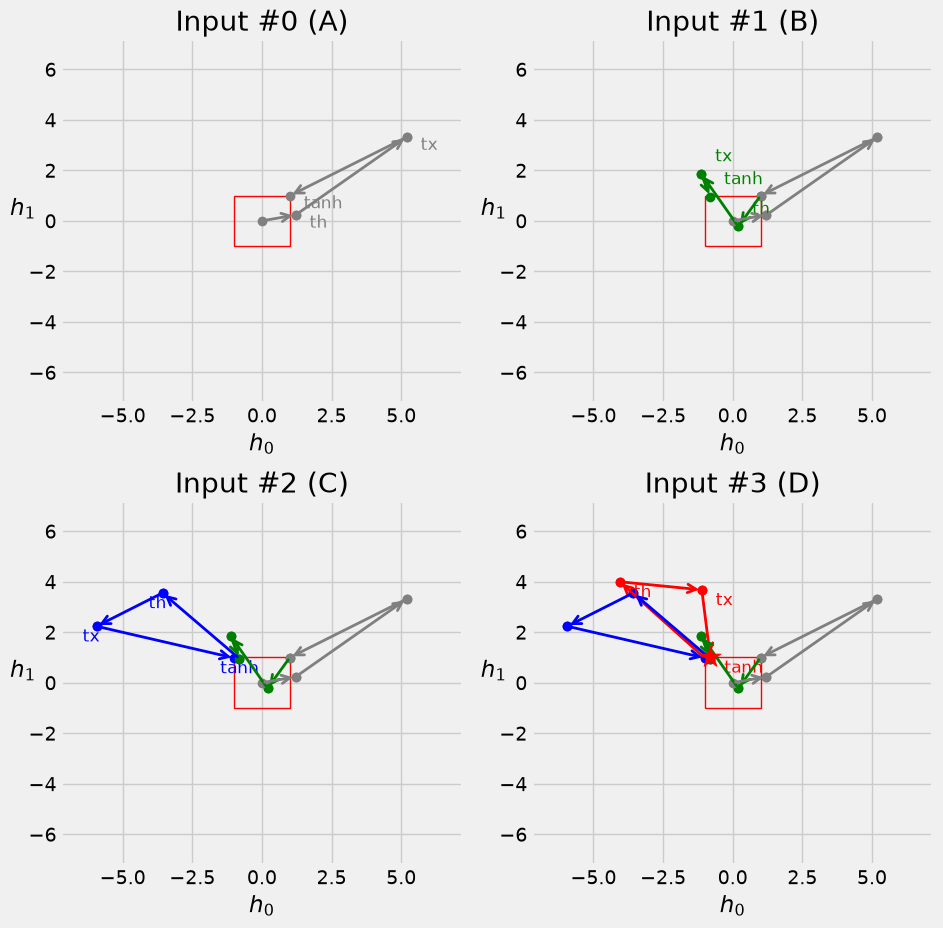

In [304]:
# 程序8-8-7: 可视化隐藏状态在特征空间中的路径轨迹

# figure17 内部流程:
#   1. 拆解训练后RNN, 取出 linear_hidden 和 linear_input
#   2. 调用 paths_clock_and_counter(only_clock=True):
#      - 构造4条顺时针序列, 分别从A/B/C/D四个角出发
#      - 对每条序列模拟RNN逐时间步处理:
#        th = linear_hidden(h)     → 隐藏层线性变换
#        tx = linear_input(x_t)    → 输入层线性变换
#        h' = tanh(th + tx)        → 新隐藏状态
#      - 在隐藏状态空间中画出每一步的轨迹:
#        th线段 → tx线段 → tanh激活线段
#
# 图中布局(2×2子图):
#   第1行(左上/右上): 分别从A和B出发的顺时针路径
#   第2行(左下/右下): 分别从C和D出发的顺时针路径
#   每个子图中矩形框: [-1,1]×[-1,1] 参考区域
#
# 轨迹解读(每个子图有3段折线×4个角点):
#   第1段(th线段): 从当前h到 W_hh@h+b_hh 的线性跳转(隐藏自变换)
#   第2段(tx线段): 加上 W_ih@x_t+b_ih 的偏移(新输入注入)
#   第3段(tanh激活): 经过tanh非线性压缩到(-1,1)范围
#   终点(★星号): 最终隐藏状态, 即RNN对完整序列的编码
#
# 设计意图: 直观展示"隐藏状态如何在特征空间中一步步移动",
#         从初始h₀=(0,0)开始, 每接收一个角点坐标后状态如何更新,
#         最终收敛到能表征"顺时针"含义的特定区域

fig = figure17(model.basic_rnn)

> 可视化RNN模型（特征空间）: 自身转换+输入转换+激活函数压缩，然后继续循环直到序列结束的过程

### 存在的问题

- 当之前隐藏状态的信息比新计算的多时
- 当数据点比隐藏状态信息多时